# Cellpose Preprocessing Figure Generation

Generates figures for `docs/cellpose_comparison.md` illustrating Suite2p preprocessing steps before Cellpose segmentation.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter, uniform_filter1d
from mbo_utilities import imread

# output directory
DOCS_IMAGES = Path("../../docs/_images/cellpose")
DOCS_IMAGES.mkdir(parents=True, exist_ok=True)

# dark theme
plt.style.use('dark_background')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 10
plt.rcParams['figure.facecolor'] = 'black'
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['savefig.facecolor'] = 'black'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'

In [4]:
# reference dataset
DATA_PATH = Path(r"\\rbo-s1\S1_DATA\lbm\kbarber\2025-11-04-mk311\raw\green")
arr = imread(DATA_PATH, fix_phase=True, use_fft=True)
print(f"Loaded: {arr.shape}")

# extract single plane
if len(arr.shape) == 4:
    data = arr[:500, 9, :, :].astype(np.float32)
else:
    data = arr[:500].astype(np.float32)

print(f"Working shape: {data.shape}")

Counting frames:   0%|          | 0/379 [00:00<?, ?it/s]

Loaded: (58825, 14, 448, 448)
Working shape: (500, 448, 448)


Zoom: y=[224:344], x=[264:384]


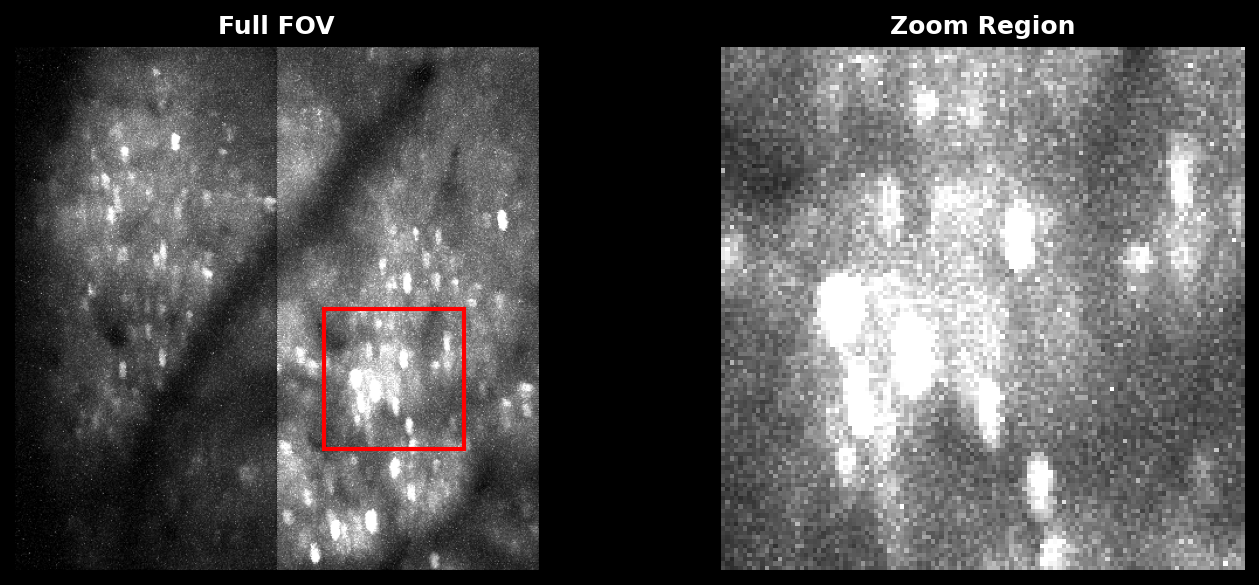

Writing video:   0%|          | 0/500 [00:00<?, ?frames/s]

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (120, 120) to (128, 128) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video saved to ..\..\docs\_images\cellpose\sample_data.mp4


In [5]:
# zoom region
ZOOM_SIZE = 120
OFFSET_X = 100
OFFSET_Y = 60

# zoom region with offset
ly, lx = data.shape[1], data.shape[2]
cy, cx = ly // 2 + OFFSET_Y, lx // 2 + OFFSET_X
y0, y1 = max(0, cy - ZOOM_SIZE // 2), min(ly, cy + ZOOM_SIZE // 2)
x0, x1 = max(0, cx - ZOOM_SIZE // 2), min(lx, cx + ZOOM_SIZE // 2)
print(f"Zoom: y=[{y0}:{y1}], x=[{x0}:{x1}]")

def zoom(img):
    return img[y0:y1, x0:x1]

def normalize99(img):
    lo, hi = np.percentile(img, [1, 99])
    return np.clip((img - lo) / (hi - lo + 1e-6), 0, 1)

def temporal_bin(mov, bin_size):
    n = mov.shape[0] // bin_size * bin_size
    return mov[:n].reshape(-1, bin_size, *mov.shape[1:]).mean(axis=1)

def temporal_high_pass_filter(mov, width):
    if width <= 0:
        return mov.copy()
    baseline = uniform_filter1d(mov, size=int(width), axis=0, mode='nearest')
    return mov - baseline

# show full image with zoom box + zoomed region
from matplotlib.patches import Rectangle
max_img = data.max(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(normalize99(max_img), cmap='gray', vmin=0, vmax=1)
axes[0].add_patch(Rectangle((x0, y0), x1-x0, y1-y0, linewidth=2, edgecolor='red', facecolor='none'))
axes[0].set_title("Full FOV", fontweight='bold')
axes[0].axis('off')

axes[1].imshow(zoom(normalize99(max_img)), cmap='gray', vmin=0, vmax=1)
axes[1].set_title("Zoom Region", fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig(DOCS_IMAGES / "zoom_region.png", bbox_inches='tight')
plt.show()

# create video of zoomed region
from mbo_utilities import to_video

# zoom the movie data and normalize
zoomed_data = data[:, y0:y1, x0:x1]
zoomed_norm = np.stack([normalize99(frame) for frame in zoomed_data])

to_video(
    zoomed_norm,
    DOCS_IMAGES / "sample_data.mp4",
    fps=30,
    cmap='gray',
)
print(f"Video saved to {DOCS_IMAGES / 'sample_data.mp4'}")

Zoom: y=[224:344], x=[264:384]


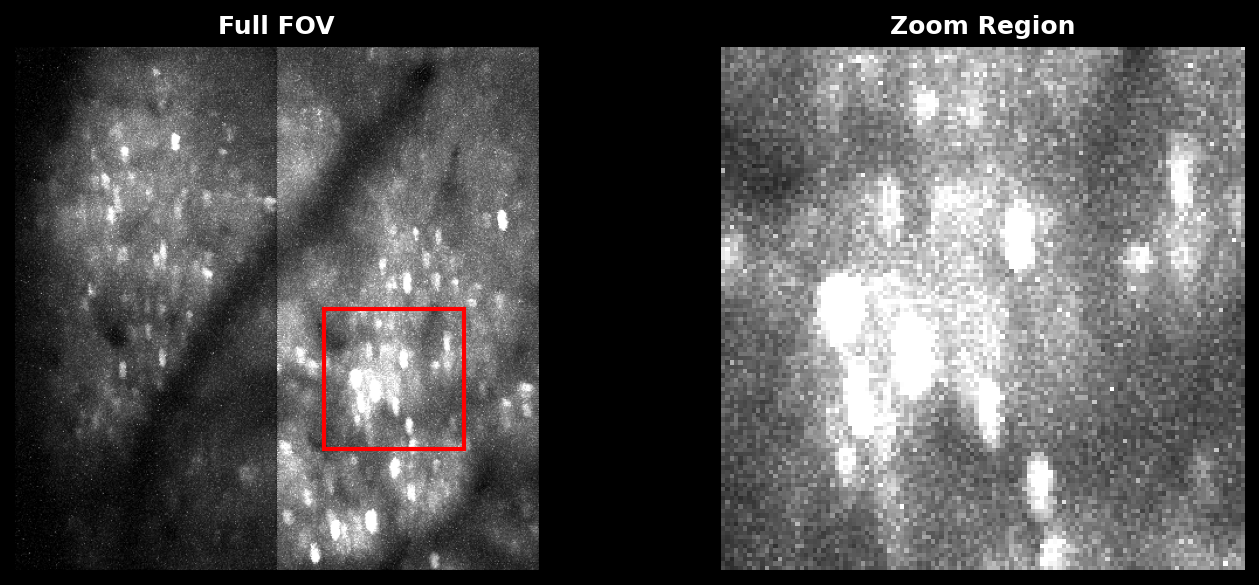

Writing video:   0%|          | 0/500 [00:00<?, ?frames/s]

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (120, 120) to (128, 128) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video saved to ..\..\docs\_images\cellpose\sample_data.mp4


In [6]:
# zoom region
ZOOM_SIZE = 120
OFFSET_X = 100
OFFSET_Y = 60

# zoom region with offset
ly, lx = data.shape[1], data.shape[2]
cy, cx = ly // 2 + OFFSET_Y, lx // 2 + OFFSET_X
y0, y1 = max(0, cy - ZOOM_SIZE // 2), min(ly, cy + ZOOM_SIZE // 2)
x0, x1 = max(0, cx - ZOOM_SIZE // 2), min(lx, cx + ZOOM_SIZE // 2)
print(f"Zoom: y=[{y0}:{y1}], x=[{x0}:{x1}]")

def zoom(img):
    return img[y0:y1, x0:x1]

def normalize99(img):
    lo, hi = np.percentile(img, [1, 99])
    return np.clip((img - lo) / (hi - lo + 1e-6), 0, 1)

def temporal_bin(mov, bin_size):
    n = mov.shape[0] // bin_size * bin_size
    return mov[:n].reshape(-1, bin_size, *mov.shape[1:]).mean(axis=1)

def temporal_high_pass_filter(mov, width):
    if width <= 0:
        return mov.copy()
    baseline = uniform_filter1d(mov, size=int(width), axis=0, mode='nearest')
    return mov - baseline

# show full image with zoom box + zoomed region
from matplotlib.patches import Rectangle
max_img = data.max(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(normalize99(max_img), cmap='gray', vmin=0, vmax=1)
axes[0].add_patch(Rectangle((x0, y0), x1-x0, y1-y0, linewidth=2, edgecolor='red', facecolor='none'))
axes[0].set_title("Full FOV", fontweight='bold')
axes[0].axis('off')

axes[1].imshow(zoom(normalize99(max_img)), cmap='gray', vmin=0, vmax=1)
axes[1].set_title("Zoom Region", fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig(DOCS_IMAGES / "zoom_region.png", bbox_inches='tight')
plt.show()

# create video of zoomed region
from mbo_utilities import to_video

zoomed_data = data[:, y0:y1, x0:x1]
zoomed_norm = np.stack([normalize99(frame) for frame in zoomed_data])

video_path = DOCS_IMAGES / "sample_data.mp4"
to_video(zoomed_norm, video_path, fps=30, cmap='gray')
print(f"Video saved to {video_path}")

# display video in jupyter
from IPython.display import Video
Video(video_path, embed=True, width=400)

## Temporal Binning

Averages consecutive frames to reduce noise:

$$\text{binned}[i] = \frac{1}{b} \sum_{j=0}^{b-1} \text{raw}[i \cdot b + j]$$

where $b$ is the bin size.

**Scale:** Values 1-20 are typical. Suite2p default targets ~1000 total binned frames.

**Use high values (10-20):** Noisy data, many frames, want faster processing  
**Use low values (1-5):** Short recordings, want to preserve transient dynamics

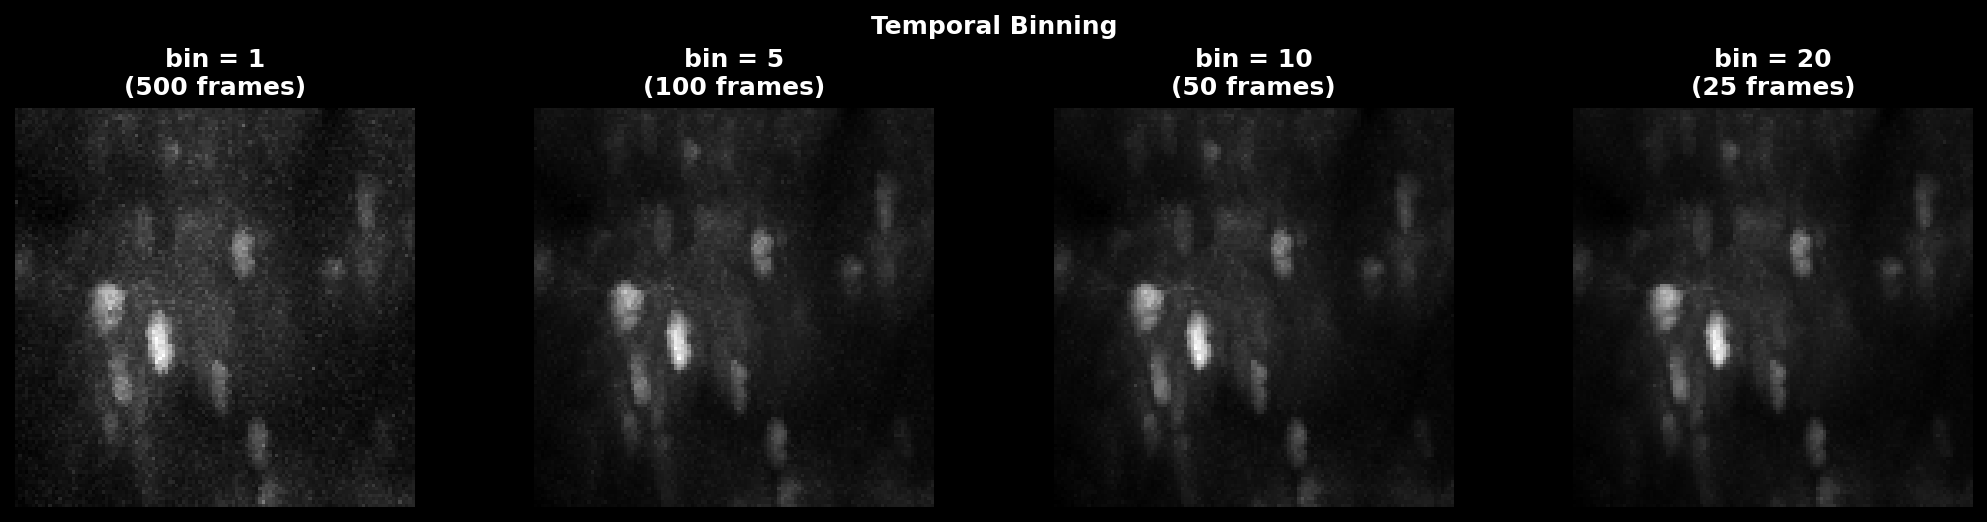

In [23]:
bin_sizes = [1, 5, 10, 20]
binned = {bs: temporal_bin(data, bs) for bs in bin_sizes}

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, bs in zip(axes, bin_sizes):
    mov_bin = binned[bs]
    ax.imshow(zoom(mov_bin.max(axis=0)), cmap='gray')
    ax.set_title(f"bin = {bs}\n({mov_bin.shape[0]} frames)", fontweight='bold')
    ax.axis('off')

plt.suptitle("Temporal Binning", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(DOCS_IMAGES / "temporal_binning.png", bbox_inches='tight')
plt.show()

---
## Temporal High-Pass Filter

Removes slow baseline drift by subtracting a running average:

$$\text{filtered}[t] = \text{raw}[t] - \frac{1}{w} \sum_{i=t-w/2}^{t+w/2} \text{raw}[i]$$

where $w$ is the filter width in frames.

**Scale:** Values 10-500 frames. Suite2p default is 100.

**Use high values (100-500):** Preserve slower dynamics, less aggressive filtering  
**Use low values (10-50):** Remove more baseline, emphasize fast transients  
**Use 0:** No filtering (keep raw dynamics)

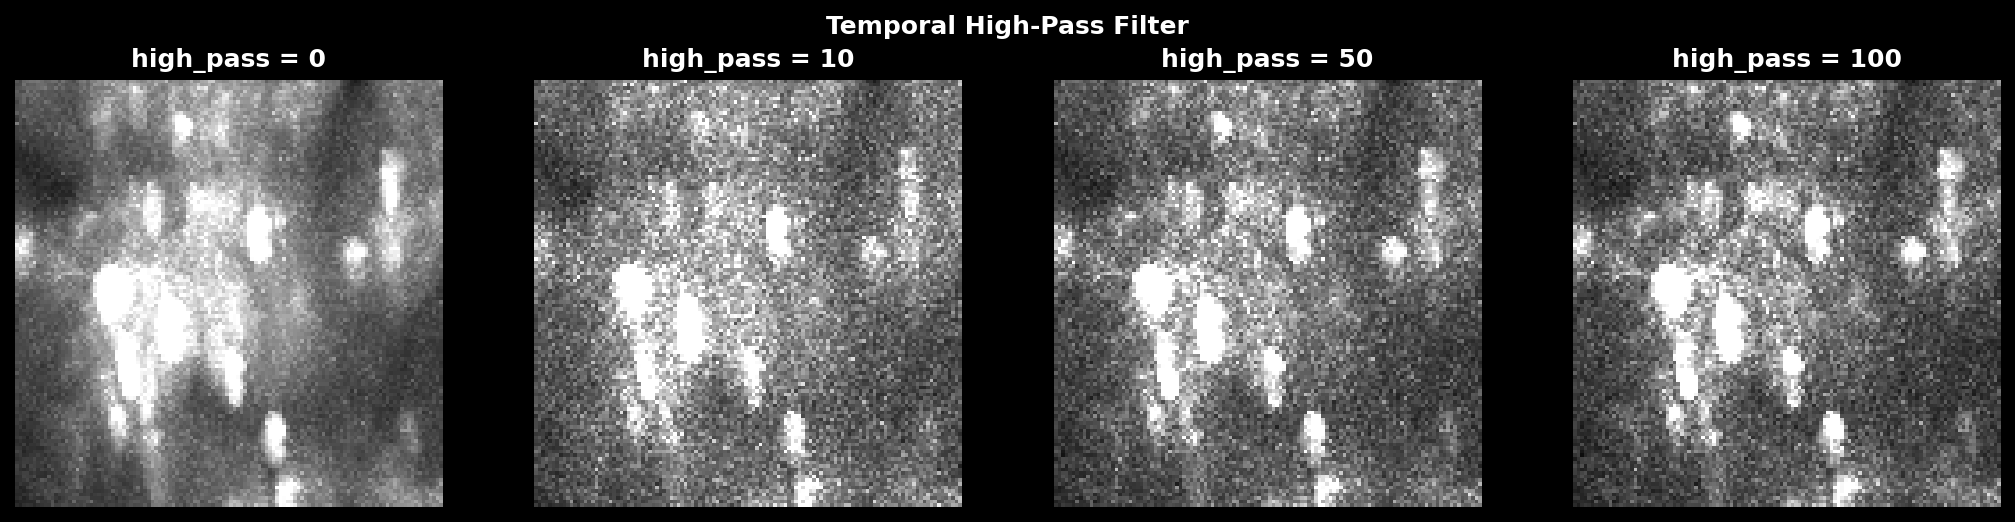

In [24]:
mov_bin = binned[5]
hp_values = [0, 10, 50, 100]

fig, axes = plt.subplots(1, len(hp_values), figsize=(14, 3.5))
for i, hp in enumerate(hp_values):
    mov_hp = temporal_high_pass_filter(mov_bin, hp)
    axes[i].imshow(zoom(normalize99(mov_hp.max(axis=0))), cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(f"high_pass = {hp}", fontweight='bold')
    axes[i].axis('off')

plt.suptitle("Temporal High-Pass Filter", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(DOCS_IMAGES / "temporal_hp.png", bbox_inches='tight')
plt.show()

---
## Anatomical Mode

Suite2p computes different images for Cellpose based on `anatomical_only`:

| Mode | Formula | Use case |
|------|---------|----------|
| 1 | $\log(\max / \text{mean})$ | Activity contrast (default) |
| 2 | $\text{mean}$ | Stable anatomy |
| 3 | $\text{enhanced mean}$ | High contrast |
| 4 | $\max$ | Direct max projection |

Mode 1 emphasizes active pixels; Mode 4 is closest to direct `lsp.cellpose()`.

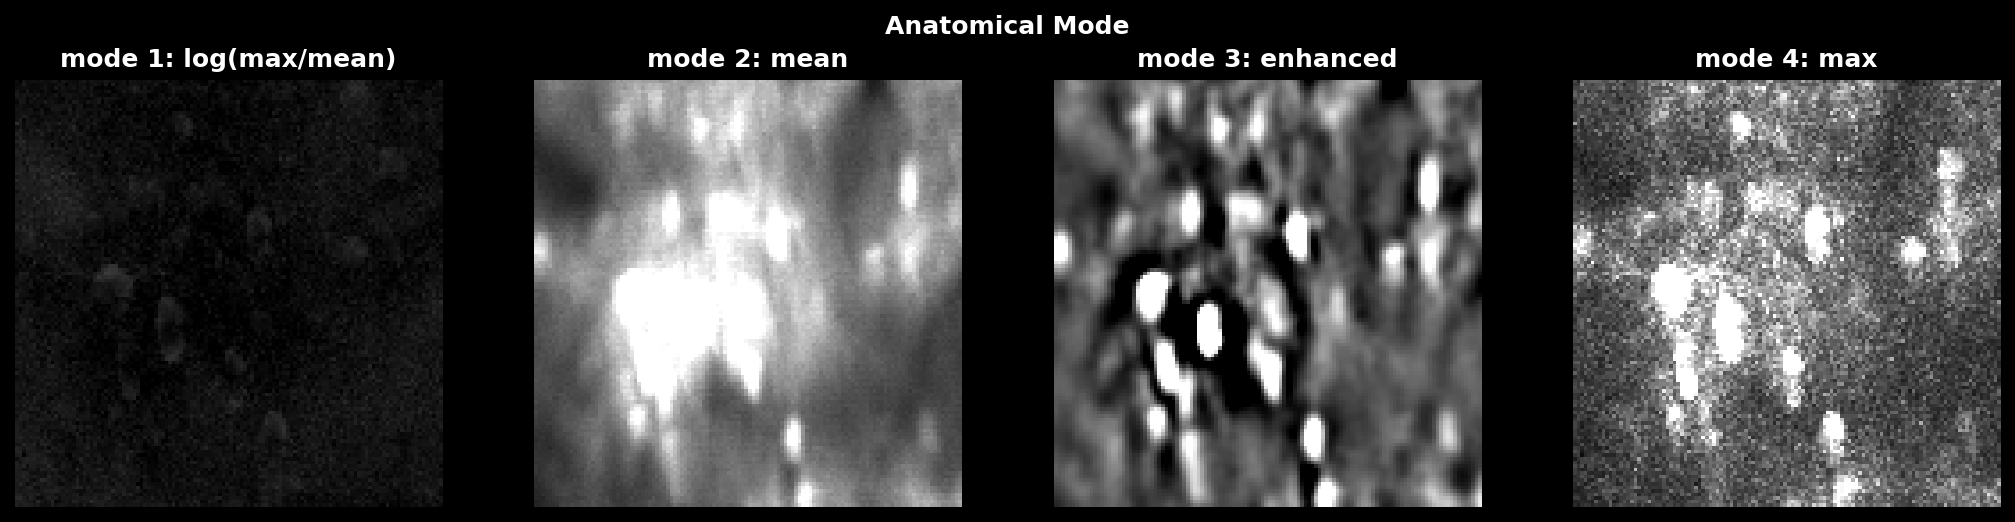

In [25]:
mov_hp = temporal_high_pass_filter(mov_bin, width=100)
mean_img = mov_bin.mean(axis=0)
max_proj = mov_hp.max(axis=0)

modes = [
    (1, np.log(np.maximum(1e-3, max_proj / np.maximum(1e-3, mean_img))), "log(max/mean)"),
    (2, mean_img, "mean"),
    (3, gaussian_filter(mean_img, 1) - gaussian_filter(mean_img, 5), "enhanced"),
    (4, max_proj, "max"),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for i, (mode, img, label) in enumerate(modes):
    axes[i].imshow(zoom(normalize99(img)), cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(f"mode {mode}: {label}", fontweight='bold')
    axes[i].axis('off')

plt.suptitle("Anatomical Mode", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(DOCS_IMAGES / "anatomical_modes.png", bbox_inches='tight')
plt.show()

---
## Spatial High-Pass Filter

Removes large-scale intensity gradients by subtracting a Gaussian-blurred version:

$$\text{filtered} = \text{img} - G_{\sigma}(\text{img})$$

where $\sigma = \text{diameter} \times \text{spatial\_hp\_cp}$.

**Scale:** Values 0-4 (multiplier on cell diameter). Suite2p default is 0 (off).

**Use 1-2:** Mild gradient removal, uneven illumination  
**Use 3-4:** Aggressive, may remove cell bodies  
**Use 0:** No spatial filtering

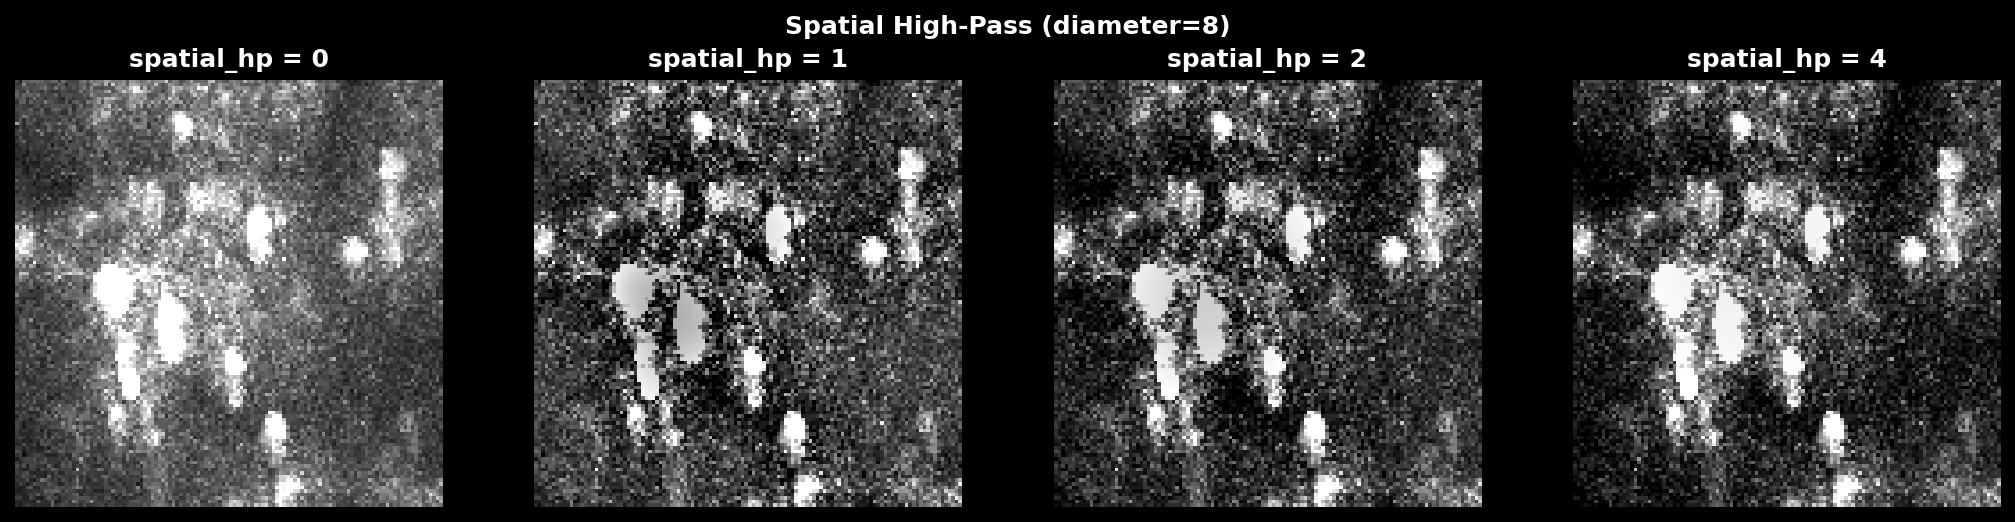

In [26]:
spatial_hp_values = [0, 1, 2, 4]
diameter = 8
img = normalize99(max_proj)

fig, axes = plt.subplots(1, len(spatial_hp_values), figsize=(14, 3.5))
for i, shp in enumerate(spatial_hp_values):
    if shp > 0:
        img_hp = img - gaussian_filter(img, diameter * shp)
    else:
        img_hp = img
    axes[i].imshow(zoom(normalize99(img_hp)), cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(f"spatial_hp = {shp}", fontweight='bold')
    axes[i].axis('off')

plt.suptitle(f"Spatial High-Pass (diameter={diameter})", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(DOCS_IMAGES / "spatial_hp.png", bbox_inches='tight')
plt.show()

---
## Projection Methods

For direct `lsp.cellpose()`, different temporal projections highlight different features:

| Method | Formula | Use case |
|--------|---------|----------|
| max | $\max_t(x)$ | Activity peaks |
| mean | $\bar{x}$ | Stable structure |
| std | $\sigma_x$ | Activity variance |
| p99 | $P_{99}(x)$ | Robust peaks |

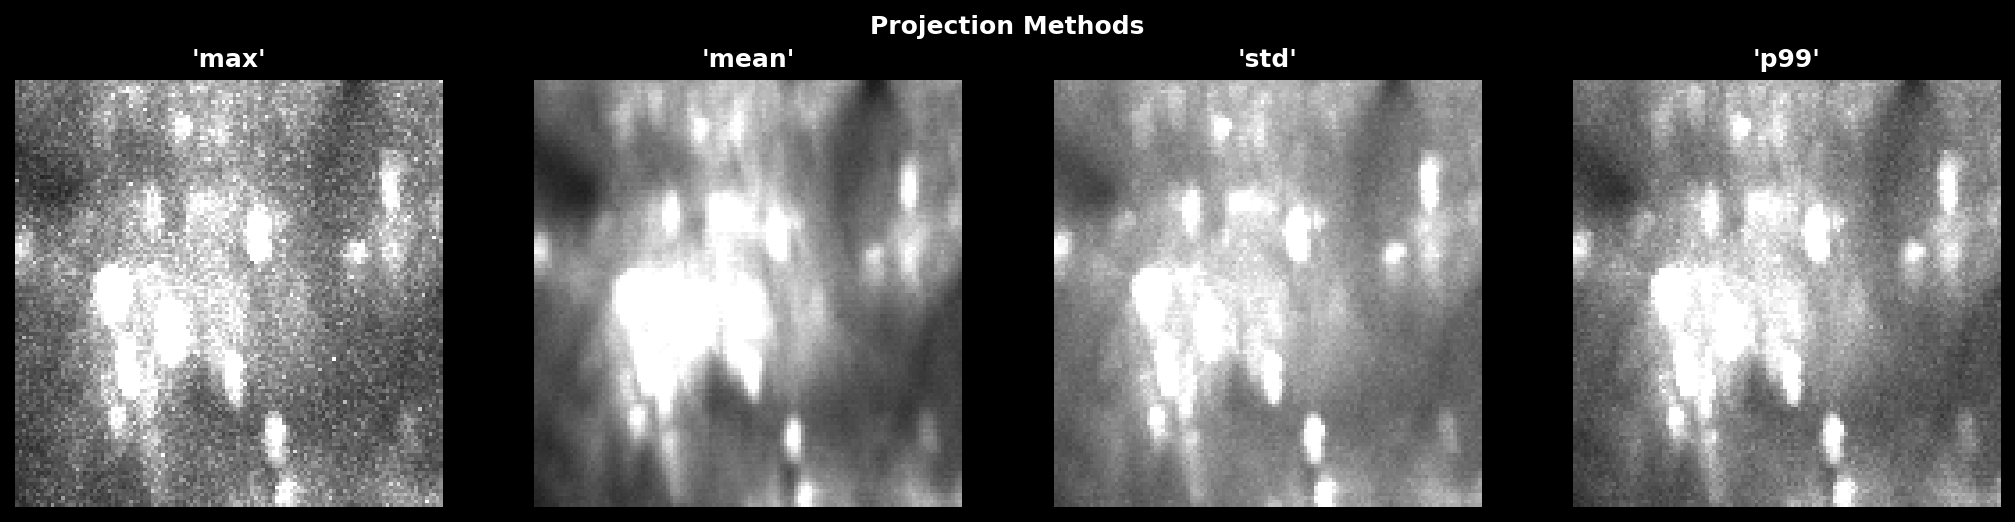

In [27]:
projections = {
    'max': data.max(axis=0),
    'mean': data.mean(axis=0),
    'std': data.std(axis=0),
    'p99': np.percentile(data, 99, axis=0),
}

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, (name, proj) in zip(axes, projections.items()):
    ax.imshow(zoom(normalize99(proj)), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"'{name}'", fontweight='bold')
    ax.axis('off')

plt.suptitle("Projection Methods", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(DOCS_IMAGES / "projection_methods.png", bbox_inches='tight')
plt.show()

---
## Segmentation Comparison

In [28]:
try:
    from cellpose import models, core
    from matplotlib.colors import ListedColormap
    CELLPOSE_AVAILABLE = True
    print(f"Cellpose available, GPU: {core.use_gpu()}")
except ImportError:
    CELLPOSE_AVAILABLE = False
    print("Cellpose not available")

Cellpose available, GPU: True


In [32]:
if CELLPOSE_AVAILABLE:
    model = models.CellposeModel(model_type='cyto3', gpu=core.use_gpu())

    images = {
        'max proj': normalize99(zoom(projections['max'])),
        'mode 1': normalize99(zoom(modes[0][1])),
        'mode 4': normalize99(zoom(modes[3][1])),
    }

    results = {}
    for name, img in images.items():
        masks, _, _ = model.eval(img, diameter=8, flow_threshold=0.4, cellprob_threshold=0.0)
        results[name] = {'img': img, 'masks': masks, 'n_cells': int(masks.max())}
        print(f"{name}: {results[name]['n_cells']} cells")

model_type argument is not used in v4.0.1+. Ignoring this argument...
Resizing is deprecated in v4.0.1+


max proj: 9 cells


Resizing is deprecated in v4.0.1+


mode 1: 0 cells


Resizing is deprecated in v4.0.1+


mode 4: 12 cells


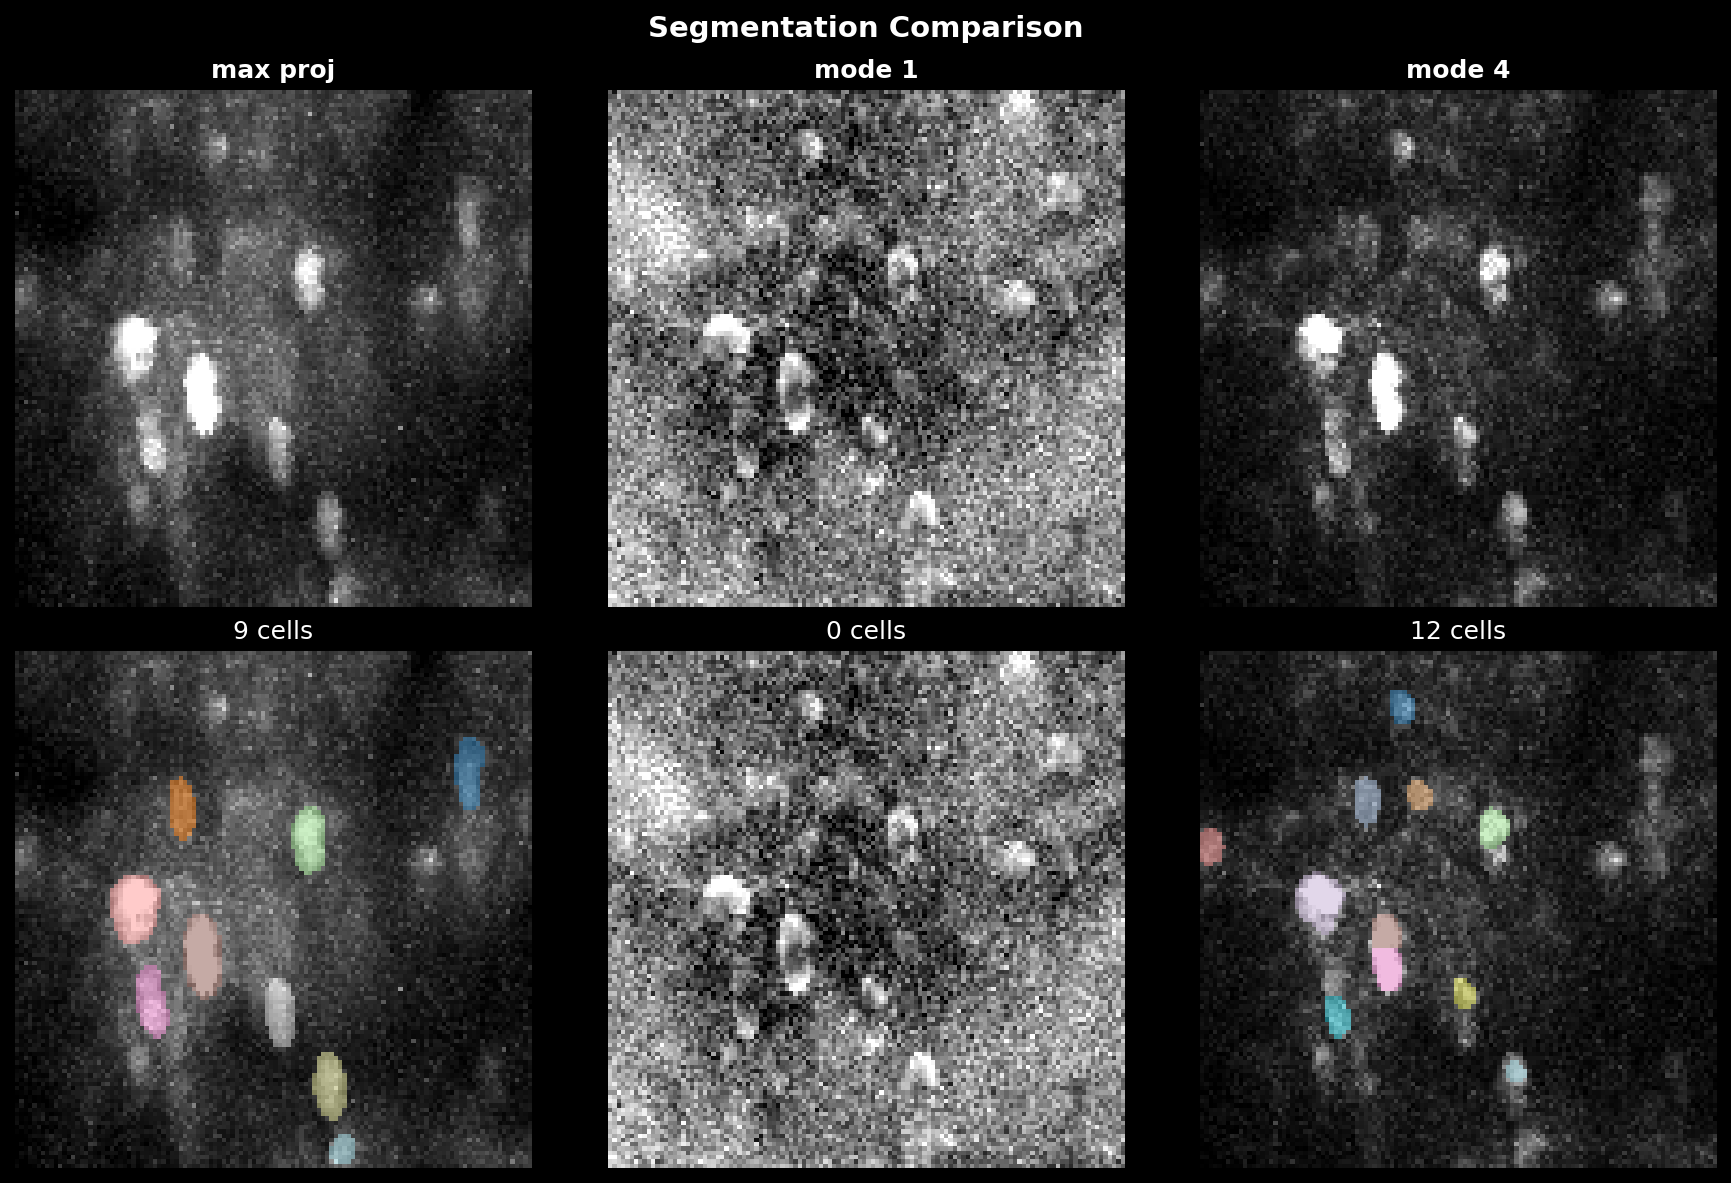

In [30]:
if CELLPOSE_AVAILABLE:
    fig, axes = plt.subplots(2, len(results), figsize=(12, 8))

    for i, (name, res) in enumerate(results.items()):
        axes[0, i].imshow(res['img'], cmap='gray', vmin=0, vmax=1)
        axes[0, i].set_title(name, fontweight='bold')
        axes[0, i].axis('off')

        n_colors = max(res['masks'].max(), 1)
        colors = plt.cm.tab20(np.linspace(0, 1, min(n_colors, 20)))
        if n_colors > 20:
            colors = np.tile(colors, (n_colors // 20 + 1, 1))[:n_colors]
        colors = np.vstack([[0, 0, 0, 0], colors])
        cmap = ListedColormap(colors)

        axes[1, i].imshow(res['img'], cmap='gray', vmin=0, vmax=1)
        axes[1, i].imshow(res['masks'], cmap=cmap, alpha=0.5, vmin=0, vmax=n_colors)
        axes[1, i].set_title(f"{res['n_cells']} cells")
        axes[1, i].axis('off')

    plt.suptitle("Segmentation Comparison", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(DOCS_IMAGES / "segmentation_comparison.png", bbox_inches='tight')
    plt.show()

In [31]:
print("Generated figures:")
for f in sorted(DOCS_IMAGES.glob("*.png")):
    print(f"  {f.name}")

Generated figures:
  anatomical_modes.png
  projection_methods.png
  segmentation_comparison.png
  spatial_hp.png
  temporal_binning.png
  temporal_hp.png
  zoom_region.png
